In [1]:
import cv2
import time
import random
from random import sample

from matplotlib import pyplot as plt
import math
import os
import numpy as np

import mediapipe as mp
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler


2025-03-27 00:07:10.536136: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743034030.557314 1474476 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743034030.563835 1474476 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743034030.578994 1474476 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743034030.579021 1474476 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743034030.579024 1474476 computation_placer.cc:177] computation placer alr

In [2]:
align_file_test = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S1/align/bbaf2s.align" 


def ParseAlign(align_file: str)-> list[bool, int, int]:
    """
    Provides Clip information for a single .align file
    Args:
        align_file: path to align file
    Returns:
        clip_alignments: [[sil,start_frame,end_frame],[sil,start_frame end_frame],[talking,start_frame,end_frame],[talking,start_frame,end_frame]]
    """

    with open(align_file, 'r') as file:
        clip_alignment = []
        start_talk=0
        end_talk=0
        for line in file:
            alignment = line.strip('\n').split(" ")
            start, end, word = alignment
            if word == "sil":
                start_frame = math.ceil(int(start)*0.001)
                end_frame = math.ceil(int(end)*0.001)
                clip_alignment.append(["sil", start_frame, end_frame])
                
            else:
                if start_talk == 0:
                    start_talk = math.ceil(int(start)*0.001)
                if math.ceil(int(end)*0.001) > end_talk:
                    end_talk = math.ceil(int(end)*0.001)
        midpoint = math.ceil(start_talk + (end_talk-start_talk)/2)
        clip_alignment.append(["talking", start_talk, midpoint])
        clip_alignment.append(["talking", midpoint, end_talk])
            

    return clip_alignment

ParseAlign(align_file=align_file_test)

[['sil', 0, 13], ['sil', 51, 75], ['talking', 13, 32], ['talking', 32, 51]]

In [3]:
FULL_GRID_DIR = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata"

def ParseDataset(path: str) -> list[bool, int, int, str]:
    """Given a formatted dataset, returns all clip infromation
    Args:
        path: path to dataset
    Returns:
        clip_alignments: [istalking: bool,start_frame:int,end_frame:int, videopath:str]"""

    dataset_abstracted = []
    for subject in os.listdir(path):
        try:
            align_folder = path + "/" + subject + "/align"
            video_folder = path + "/" + subject + "/" + subject
            for filename in os.listdir(align_folder):
                video_clip_name = filename.split(".")[0]+".mpg"
                video_path = video_folder + "/"+ video_clip_name
                alignments = ParseAlign(align_folder+"/"+filename)
                if os.path.isfile(video_path): #Try video path except skip
                    for alignment in alignments:
                        clip_values = [*alignment, video_path]
                        dataset_abstracted.append(clip_values)

        except Exception as e:
            print("Exception Error:", e)

    return dataset_abstracted

dataset_values = ParseDataset(FULL_GRID_DIR)
print(dataset_values[0])



['sil', 0, 14, '/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S4/S4/bbae9n.mpg']


In [4]:
MOUTH_LANDMARKS = [0, 267, 269, 270, 409, 306, 375, 321, 405, 314, 17, 84, 181, 91, 146, 61, 185, 40, 39,
                                37]

mpDraw = mp.solutions.drawing_utils
mpFaceMesh = mp.solutions.face_mesh
faceMesh = mpFaceMesh.FaceMesh(max_num_faces=2)
drawSpec = mpDraw.DrawingSpec(thickness=1, circle_radius=1)

def FindMouth(img, output_format):
    landmarks = []
    radiandistance = []
    try:
        results = faceMesh.process(img)
        if results.multi_face_landmarks:
            for faceLms in results.multi_face_landmarks:
                # mpDraw.draw_landmarks(img, faceLms, mpFaceMesh.FACEMESH_CONTOURS, drawSpec, drawSpec)
                for id,lm in enumerate(faceLms.landmark):
                    image_height, image_width, image_channels = img.shape
                    x,y = int(lm.x*image_width), int(lm.y*image_height)
                    if output_format == "mouthrgb":
                        if id == 0:
                            return img[y-40:y+60,x-50:x+50,:]
                    if output_format == "liplandmarks":
                        if id in MOUTH_LANDMARKS:
                            landmarks.append((x,y))
            if landmarks:
                for x,y in landmarks:
                    x2,y2 = landmarks[0]
                    deltaX, deltaY = ((x2-x)**2), ((y2-y)**2)
                    radian = math.atan2(deltaY, deltaX)
                    radiandistance.append((math.dist((x,y),(x2,y2))))
                return radiandistance
    except Exception as e:
        print("Failed to FindMouth:", e)
    return None
        

I0000 00:00:1743034036.170100 1474476 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1743034036.310855 1474633 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.120), renderer: NVIDIA GeForce RTX 4070/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [5]:
# frameformats -> mouthrgb, mouthgreyscale, liplandmarks, fullframe/face



class FrameGenerator():
    """Given an array of dataset values, returns labeled and formatted data/frames"""
    def __init__(self, dataset_values, training=False, frame_format="mouthrgb"):
        self.dataset_values = dataset_values
        self.training = training
        self.frame_format = frame_format
        
        match self.frame_format:
            case "mouthrgb":
                self.input_shape = (10, 100, 100, 3)
            case "liplandmarks":
                self.input_shape = (10, 20, 2)
                


    def __call__(self):
        if self.training:
            np.random.shuffle(self.dataset_values) #Use a different shuffle method?
            # print((self.dataset_values[0]))

        FailedReads = 0
        SuccessfullReads = 0
        ShapeIssues = 0

        # print("Test dataset format" ,self.dataset_values)
        for isTalking, start_frame, end_frame, video_path in self.dataset_values:
            label = np.int16(0 if isTalking == "sil" else 1) 
            formatted_frames = []

            cap = cv2.VideoCapture(video_path)
            count = 0
            while count < self.input_shape[0]:
                cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame+count)
                ret, frame = cap.read()
                if not ret:
                    # print("failed to read: " + video_path + str(count))
                    FailedReads += 1
                    # time.sleep(1)
                    formatted_frames.append(np.zeros((self.input_shape[1],self.input_shape[2]), dtype=np.float32))
                else:
                    SuccessfullReads += 1
                    frame = FindMouth(frame, self.frame_format)
                    if frame is None:
                        formatted_frames.append(np.zeros((self.input_shape[1],self.input_shape[2]), dtype=np.float32))
                    else:
                        if self.frame_format == "mouthrgb":
                            frame = frame / 255
                            frame = tf.image.resize_with_pad(frame,self.input_shape[1],self.input_shape[2]) 
                            frame = tf.image.convert_image_dtype(frame, tf.float32)
                        if self.frame_format == "liplandmarks":
                            frame = np.array(frame, dtype=np.float32)
                            pass
                        if frame.shape == (self.input_shape[1],self.input_shape[2]):
                            formatted_frames.append(frame)
                        else:
                            ShapeIssues += 1
                count += 1

            cap.release()

            while len(formatted_frames) < 10:
                formatted_frames.append(np.zeros((self.input_shape[1], self.input_shape[2]), dtype=np.float32))

            formatted_frames = np.array(formatted_frames, dtype=np.float32)
            # print(formatted_frames)
            # if self.frame_format == "mouthrgb":
            #     formatted_frames = np.array(formatted_frames)[...,[2,1,0]]
            print("Successful Reads:", SuccessfullReads, "Failed Reads:", FailedReads, "Shape Issues:", ShapeIssues)
            yield formatted_frames, label

    




print(len(dataset_values))
train_dataset_values = sample(dataset_values, 8000)
val_dataset_values = sample(dataset_values, 2000)
print(len(train_dataset_values), len(val_dataset_values))                    

fg = FrameGenerator(dataset_values, True, "liplandmarks")

first_item, label = next(fg())

print(first_item.shape, label)
# print(label)        

W0000 00:00:1743034036.317413 1474623 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1743034036.334925 1474629 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


120000
8000 2000
Successful Reads: 10 Failed Reads: 0 Shape Issues: 10
(10, 20, 2) 0


W0000 00:00:1743034036.934254 1474621 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [6]:
# train_ds = train_ds.batch(2)
# val_ds = val_ds.batch(2)

input_shape = (10, 20, 2)

output_signature = (tf.TensorSpec(shape = input_shape, dtype = tf.float32, name="frames"),
                    tf.TensorSpec(shape = (), dtype = tf.int16, name="labels"))
train_ds = tf.data.Dataset.from_generator(FrameGenerator(train_dataset_values, True, "liplandmarks"),
                                          output_signature = output_signature)
val_ds = tf.data.Dataset.from_generator(FrameGenerator(val_dataset_values, True, "liplandmarks"),
                                          output_signature = output_signature)

print(train_ds)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)
print(train_ds)
val_ds = val_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)

<_FlatMapDataset element_spec=(TensorSpec(shape=(10, 20, 2), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(10, 20, 2), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>


I0000 00:00:1743034037.251190 1474476 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 300 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


In [7]:
train_ds = train_ds.batch(2)
val_ds = val_ds.batch(2)

# print("Frames shape:", frames.shape)  # Should be (10, 100, 100, 3)
# print("Labels:", labels)  # Should be a single int16 label
for i in range(10):
    print(train_ds.take(i))

<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(s

In [8]:



model = models.Sequential([

    TimeDistributed(Flatten(), input_shape=input_shape),
        
    # Bidirectional LSTM to capture temporal patterns in lip movements
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    
    # Second LSTM layer to further process the sequence
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Dense layers for classification
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification (talking or not)
    # Change from softmax to sigmoid
])

# Compile Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),  # Change loss function
              metrics=['accuracy'])

# Model Summary
history = model.fit(train_ds, 
          epochs = 50,
          validation_data = val_ds,
          callbacks = tf.keras.callbacks.EarlyStopping(patience = 5, monitor = 'val_loss'))

/home/tymstr/.local/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
Successful Reads: 10 Failed Reads: 0 Shape Issues: 10
Successful Reads: 20 Failed Reads: 0 Shape Issues: 20
Successful Reads: 30 Failed Reads: 0 Shape Issues: 30
Successful Reads: 40 Failed Reads: 0 Shape Issues: 40
Successful Reads: 50 Failed Reads: 0 Shape Issues: 41
Successful Reads: 60 Failed Reads: 0 Shape Issues: 51
Successful Reads: 70 Failed Reads: 0 Shape Issues: 61
Successful Reads: 80 Failed Reads: 0 Shape Issues: 71
Successful Reads: 90 Failed Reads: 0 Shape Issues: 81
Successful Reads: 100 Failed Reads: 0 Shape Issues: 91
Successful Reads: 105 Failed Reads: 5 Shape Issues: 96
Successful Reads: 115 Failed Reads: 5 Shape Issues: 106
Successful Reads: 125 Failed Reads: 5 Shape Issues: 116
Successful Reads: 135 Failed Reads: 5 Shape Issues: 126
Successful Reads: 145 Failed Reads: 5 Shape Issues: 136
Successful Reads: 155 Failed Reads: 5 Shape Issues: 146
Successful Reads: 165 Failed Reads: 5 Shape Issues: 146
Successful Reads: 175 Failed Reads: 5 Shape Issues: 156
S

2025-03-27 00:07:32.653042: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 102 of 1000


Successful Reads: 1026 Failed Reads: 14 Shape Issues: 946
Successful Reads: 1036 Failed Reads: 14 Shape Issues: 956
Successful Reads: 1046 Failed Reads: 14 Shape Issues: 966
Successful Reads: 1056 Failed Reads: 14 Shape Issues: 976
Successful Reads: 1066 Failed Reads: 14 Shape Issues: 986
Successful Reads: 1076 Failed Reads: 14 Shape Issues: 996
Successful Reads: 1086 Failed Reads: 14 Shape Issues: 1006
Successful Reads: 1096 Failed Reads: 14 Shape Issues: 1016
Successful Reads: 1106 Failed Reads: 14 Shape Issues: 1026
Successful Reads: 1116 Failed Reads: 14 Shape Issues: 1036
Successful Reads: 1116 Failed Reads: 24 Shape Issues: 1036
Successful Reads: 1126 Failed Reads: 24 Shape Issues: 1046
Successful Reads: 1136 Failed Reads: 24 Shape Issues: 1056
Successful Reads: 1146 Failed Reads: 24 Shape Issues: 1066
Successful Reads: 1156 Failed Reads: 24 Shape Issues: 1076
Successful Reads: 1166 Failed Reads: 24 Shape Issues: 1086
Successful Reads: 1176 Failed Reads: 24 Shape Issues: 1096
Suc

2025-03-27 00:07:52.666727: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 318 of 1000


...

2025-03-27 00:28:09.166275: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16321078850627717199
2025-03-27 00:28:09.166301: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17759445155782718407


4000/4000 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.5068 - loss: 0.6933 - val_accuracy: 0.5030 - val_loss: 0.6933
Epoch 11/50
  18/4000 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - accuracy: 0.4613 - loss: 0.6932 

2025-03-27 00:28:49.281439: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16321078850627717199
2025-03-27 00:28:49.281459: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8036473666716913751
2025-03-27 00:28:49.281465: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17759445155782718407


4000/4000 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.5042 - loss: 0.6931 - val_accuracy: 0.5030 - val_loss: 0.6935


2025-03-27 00:29:29.447529: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16321078850627717199
2025-03-27 00:29:29.447551: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17759445155782718407


In [9]:
model.save_weights('./test.weights.h5')

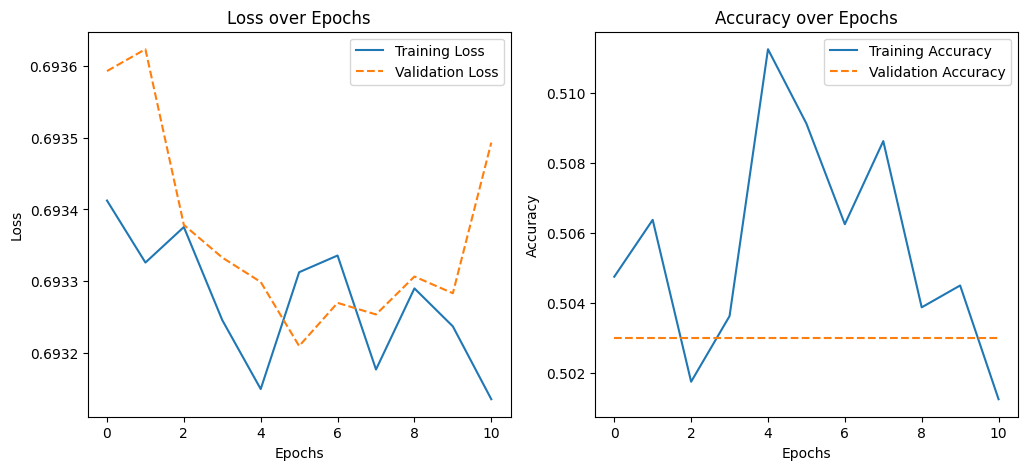

In [10]:
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')

    plt.show()

# Call the function
plot_history(history)

In [11]:
for i in range(1, 10):
    next_item, label = next(fg())
    prediction = model.predict(next_item)
    print("Prediction:", prediction[0][0], "Label", label)

Successful Reads: 10 Failed Reads: 0 Shape Issues: 10


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(10, 20, 2), dtype=float32). Expected shape (None, 10, 20, 2), but input has incompatible shape (10, 20, 2)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(10, 20, 2), dtype=float32)
  • training=False
  • mask=None

In [11]:
# input_shape=(10, 100, 100, 3)
# input_data="Mouth_RGB"
# def ReadFrames(full_path: str, start, end, isTalking):
#     video = cv2.VideoCapture(full_path)
#     frames = []
#     count = 0
#     while count < input_shape[0] and count <= end:
#         video.set(cv2.CAP_PROP_POS_FRAMES, start+count)
#         ret, frame = video.read()
#         if not ret:
#             break
#             # continue
        

#     frames.append(frame)

    
#     res, frame = video.read()

#     if not res:
#         print("failed to read")
    
   
    # video.release()
# Given a file, start and end frame, produce a len10 array of frames